In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv('AirPassengers.csv')

In [3]:
data.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [4]:
data['Month']=pd.to_datetime(data['Month'])

In [5]:
data.set_index('Month',inplace=True)

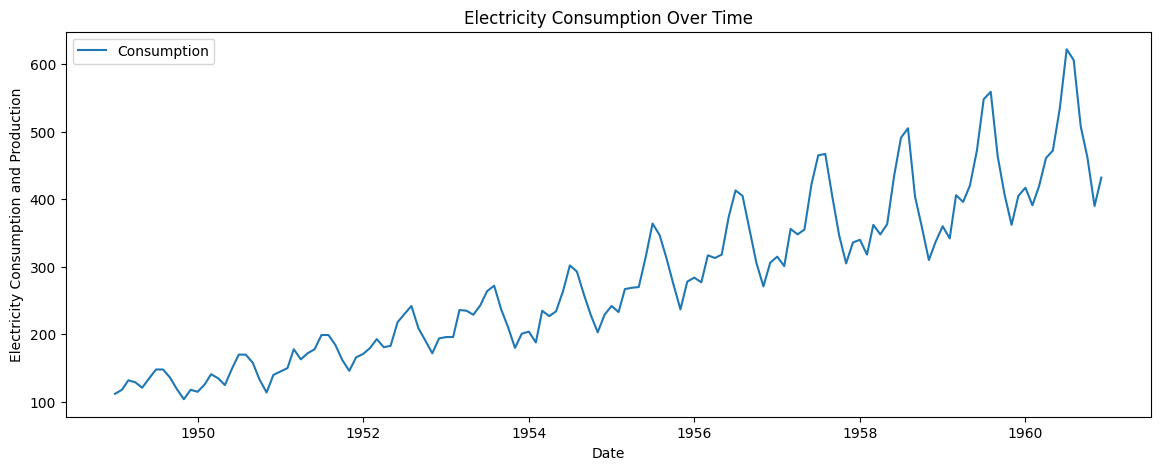

In [6]:
plt.figure(figsize=(14,5))
plt.plot(data.index,data,label='Consumption')

plt.xlabel("Date")
plt.ylabel("Electricity Consumption and Production")
plt.title("Electricity Consumption Over Time")
plt.legend()
plt.show()

In [7]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

In [8]:
scaled_data = scaler.fit_transform(data)

In [9]:
data_scaled =scaled_data.reshape(-1, 1)

In [10]:
data_scaled.shape

(144, 1)

In [11]:
import numpy as np
window = 24
X = [] 
y = []
for i in range(window, len(data_scaled)): 
    X.append(data_scaled[i-window:i]) 
    y.append(data_scaled[i]) 
X = np.array(X)
y = np.array(y)

In [12]:
X.shape

(120, 24, 1)

In [13]:
y.shape

(120, 1)

In [14]:
window = 24

# Dates corresponding to y
dates = data.index[window:]

# Split positions
train_end = int(len(X) * 0.7)
val_end = int(len(X) * 0.85)

# Training
X_train = X[:train_end]
y_train = y[:train_end]
dates_train = dates[:train_end]

# Validation
X_val = X[train_end:val_end]
y_val = y[train_end:val_end]
dates_val = dates[train_end:val_end]

# Test
X_test = X[val_end:]
y_test = y[val_end:]
dates_test = dates[val_end:]

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [16]:
model = Sequential([
    GRU(32, input_shape=(24, 1), return_sequences=True),
    Dropout(0.2),

    GRU(16),
    Dropout(0.2),

    Dense(16, activation="relu"),
    Dense(8,activation="relu"),
    Dense(4,activation="relu"),
    # Dense(2,activation="relu"),
    Dense(1)
])

C:\Users\Mcc\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
model.compile(
    optimizer="adamW",
    loss="mse",
    metrics=["mae"]
)

In [18]:
X_train.shape,y_train.shape,X_test.shape,y_test.shape,dates_train.shape,dates_test.shape

((84, 24, 1), (84, 1), (18, 24, 1), (18, 1), (84,), (18,))

In [19]:
dates_test

DatetimeIndex(['1959-07-01', '1959-08-01', '1959-09-01', '1959-10-01',
               '1959-11-01', '1959-12-01', '1960-01-01', '1960-02-01',
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', freq=None)

In [20]:
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=15,
    min_lr=1e-6
)



In [21]:
history = model.fit(
    X_train,
    y_train,
    epochs=300,
    batch_size=8,
    validation_data=(X_val, y_val),
    shuffle=False,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 182ms/step - loss: 0.0813 - mae: 0.2592 - val_loss: 0.1852 - val_mae: 0.4162 - learning_rate: 0.0010
Epoch 2/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0265 - mae: 0.1284 - val_loss: 0.0620 - val_mae: 0.2226 - learning_rate: 0.0010
Epoch 3/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0109 - mae: 0.0817 - val_loss: 0.0198 - val_mae: 0.1031 - learning_rate: 0.0010
Epoch 4/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0199 - mae: 0.1156 - val_loss: 0.0303 - val_mae: 0.1379 - learning_rate: 0.0010
Epoch 5/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0149 - mae: 0.0967 - val_loss: 0.0387 - val_mae: 0.1634 - learning_rate: 0.0010
Epoch 6/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0120 - mae: 0.0855 - val_loss: 0.0284 - val_mae: 0.1314 - learning_rate: 0.0010
Epoch 7/300
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0114 - mae: 0.0878 - val_loss: 0.0255 - val_mae: 0.1218 - learning_rate: 0.0010
Epoc

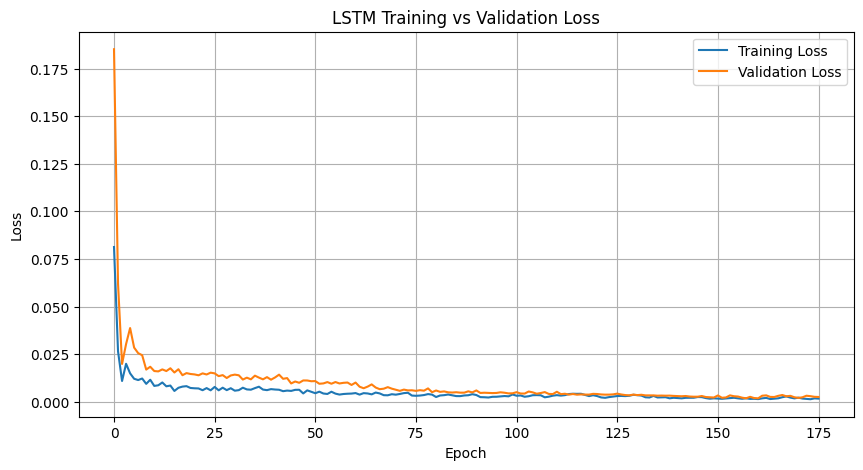

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [23]:
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 962ms/step


In [24]:
y_pred_actual = scaler.inverse_transform(y_pred)
y_test_actual = scaler.inverse_transform(y_test)

In [25]:
y_pred_actual.shape

(18, 1)

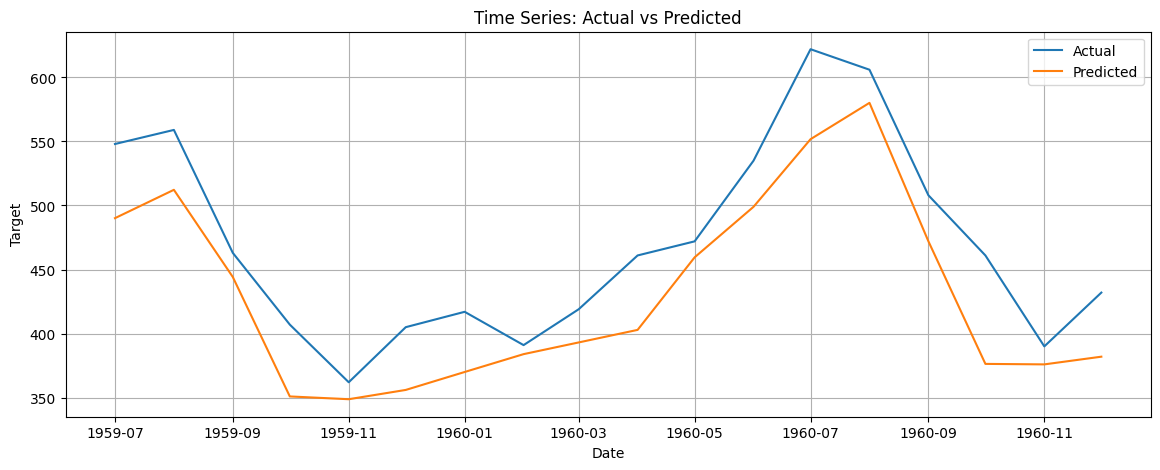

In [26]:

plt.figure(figsize=(14, 5))

plt.plot(dates_test,y_test_actual, label="Actual")
plt.plot(dates_test, y_pred_actual, label="Predicted")

plt.xlabel("Date")
plt.ylabel("Target")
plt.title("Time Series: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(
    y_test_actual,
    y_pred_actual
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_pred_actual
    )
)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 39.39691670735677
RMSE: 44.804816821666904


In [28]:
y_pred_actual

array([[490.11163],
       [512.2369 ],
       [444.17255],
       [350.9275 ],
       [348.75198],
       [356.00488],
       [370.01285],
       [383.94724],
       [393.08612],
       [402.88278],
       [459.52164],
       [498.9823 ],
       [551.76556],
       [580.1295 ],
       [472.079  ],
       [376.333  ],
       [375.94965],
       [381.96042]], dtype=float32)

In [29]:
last_sequence = data_scaled[-12:].copy()

future_predictions = []

for i in range(12):

    X_future = last_sequence.reshape(1, 12, 1)

    pred = model.predict(X_future, verbose=0)

    future_predictions.append(pred[0, 0])

    # Remove oldest month
    # and add the new prediction
    last_sequence = np.append(
        last_sequence[1:],
        pred[0]
    )

In [30]:
future_predictions = np.array(
    future_predictions
).reshape(-1, 1)

future_predictions = scaler.inverse_transform(
    future_predictions
)

In [31]:
print(future_predictions)

[[401.52148]
 [412.60956]
 [423.26404]
 [430.04254]
 [444.01797]
 [483.41946]
 [515.9962 ]
 [501.07742]
 [432.32162]
 [383.3794 ]
 [378.2242 ]
 [381.30563]]


In [32]:
last_date = data.index[-1]

In [33]:
future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

In [34]:


future_df = pd.DataFrame({
    "Month": future_dates,
    "Predicted_Passengers": future_predictions.flatten()
})

print(future_df)

        Month  Predicted_Passengers
0  1961-01-01            401.521484
1  1961-02-01            412.609558
2  1961-03-01            423.264038
3  1961-04-01            430.042542
4  1961-05-01            444.017975
5  1961-06-01            483.419464
6  1961-07-01            515.996216
7  1961-08-01            501.077423
8  1961-09-01            432.321625
9  1961-10-01            383.379395
10 1961-11-01            378.224213
11 1961-12-01            381.305634


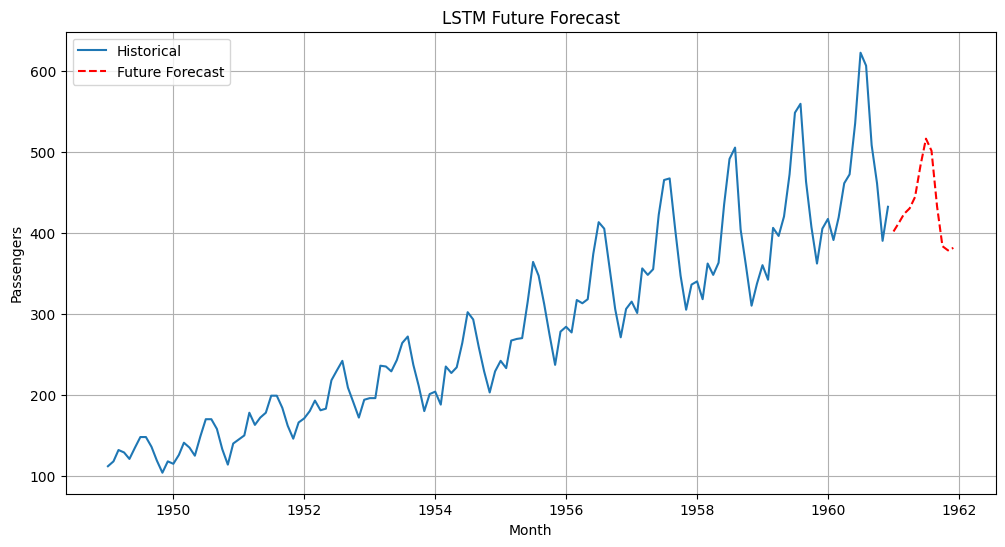

In [35]:
plt.figure(figsize=(12, 6))

plt.plot(
    data.index,
    data["#Passengers"],
    label="Historical"
)

plt.plot(
    future_df['Month'],
    future_df["Predicted_Passengers"],
    color="red",
    label="Future Forecast",
    linestyle='--'
)

plt.xlabel("Month")
plt.ylabel("Passengers")
plt.title("LSTM Future Forecast")
plt.legend()
plt.grid(True)

plt.show()